In [ ]:
import scanpy as sc
import numpy as np

adata = sc.read_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/temp.MC.raw_counts.h5ad"
)

adata
adata.obs["sample_key"].value_counts()
adata.obs["devTime"].value_counts()
adata.obs["EML"].value_counts()
adata.obsm.keys()

x = adata.X.data
np.mean(np.isclose(x, np.round(x)))
adata.X.max()

np.float64(83554.0)

In [ ]:
import scanpy as sc

adata = sc.read_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/temp.MC.raw_counts.h5ad"
)

adata.layers["counts"] = adata.X.copy()
adata.raw = adata.copy()

adata.write_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/temp.MC.raw_counts.h5ad"
)

In [ ]:
adata.obs

,Hcell,EML,sub_em_cluster,sub_Ery_cluster,D3_x,D3_y,D3_z,devTime,pj,sample_key,metacell_id,sub_EML,x,y,z
CS7.3D.SEACell.0__MSsub_1,CS7.3D.SEACell.0__MSsub_1,YS.Endo,nan,nan,-197.534231,-56.575577,403.076923,CS7,Cui_CS7.3D,Cui_CS7.3D,CS7.3D.SEACell.0__MSsub_1,NaN,NaN,NaN,NaN
CS7.3D.SEACell.1__MSsub_3,CS7.3D.SEACell.1__MSsub_3,YS.Endo,nan,nan,-738.888182,-11.204242,1140.606061,CS7,Cui_CS7.3D,Cui_CS7.3D,CS7.3D.SEACell.1__MSsub_3,NaN,NaN,NaN,NaN
CS7.3D.SEACell.10__MSsub_1,CS7.3D.SEACell.10__MSsub_1,YS.Endo,nan,YS.Endo.MP,178.547857,-114.109286,25.714286,CS7,Cui_CS7.3D,Cui_CS7.3D,CS7.3D.SEACell.10__MSsub_1,NaN,NaN,NaN,NaN
CS7.3D.SEACell.100__MSsub_2,CS7.3D.SEACell.100__MSsub_2,Epi/Ecto,Epi,nan,279.513333,-59.881000,1869.333333,CS7,Cui_CS7.3D,Cui_CS7.3D,CS7.3D.SEACell.100__MSsub_2,NaN,NaN,NaN,NaN
CS7.3D.SEACell.101__MSsub_1,CS7.3D.SEACell.101__MSsub_1,Ery,nan,Erythroblast,-289.649474,347.848421,258.947368,CS7,Cui_CS7.3D,Cui_CS7.3D,CS7.3D.SEACell.101__MSsub_1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CS9.3D.SEACell.997__MSsub_2,CS9.3D.SEACell.997__MSsub_2,EXE.Meso-1,NaN,NaN,25.524575,14.917780,10.461538,CS9.spatial,Yuan_CS9,Yuan_CS9,CS9.3D.SEACell.997__MSsub_2,NaN,25.524575,14.917780,10.461538
CS9.3D.SEACell.997__MSsub_3,CS9.3D.SEACell.997__MSsub_3,EXE.Meso-1,NaN,NaN,32.087574,21.790060,9.200000,CS9.spatial,Yuan_CS9,Yuan_CS9,CS9.3D.SEACell.997__MSsub_3,NaN,32.087574,21.790060,9.200000
CS9.3D.SEACell.998__MSsub_3,CS9.3D.SEACell.998__MSsub_3,EXE.Meso-1,NaN,NaN,30.381853,30.277213,47.191209,CS9.spatial,Yuan_CS9,Yuan_CS9,CS9.3D.SEACell.998__MSsub_3,NaN,30.381853,30.277213,47.191209
CS9.3D.SEACell.999__MSsub_1,CS9.3D.SEACell.999__MSsub_1,Car.Meso,NaN,NaN,28.928561,6.536721,18.400000,CS9.spatial,Yuan_CS9,Yuan_CS9,CS9.3D.SEACell.999__MSsub_1,NaN,28.928561,6.536721,18.400000


In [ ]:
adata

AnnData object with n_obs × n_vars = 3106 × 30212
    obs: 'Hcell', 'EML', 'sub_em_cluster', 'sub_Ery_cluster', 'D3_x', 'D3_y', 'D3_z', 'devTime', 'pj', 'sample_key', 'metacell_id', 'sub_EML', 'x', 'y', 'z'
    uns: 'X_name'
    obsm: 'spatial3D'
    layers: 'counts'

In [ ]:
adata.obsm['spatial3D']

,D3_x,D3_y,D3_z
CS7.3D.SEACell.0__MSsub_1,-197.534231,-56.575577,403.076923
CS7.3D.SEACell.1__MSsub_3,-738.888182,-11.204242,1140.606061
CS7.3D.SEACell.10__MSsub_1,178.547857,-114.109286,25.714286
CS7.3D.SEACell.100__MSsub_2,279.513333,-59.881000,1869.333333
CS7.3D.SEACell.101__MSsub_1,-289.649474,347.848421,258.947368
...,...,...,...
CS9.3D.SEACell.997__MSsub_2,25.524575,14.917780,10.461538
CS9.3D.SEACell.997__MSsub_3,32.087574,21.790060,9.200000
CS9.3D.SEACell.998__MSsub_3,30.381853,30.277213,47.191209
CS9.3D.SEACell.999__MSsub_1,28.928561,6.536721,18.400000


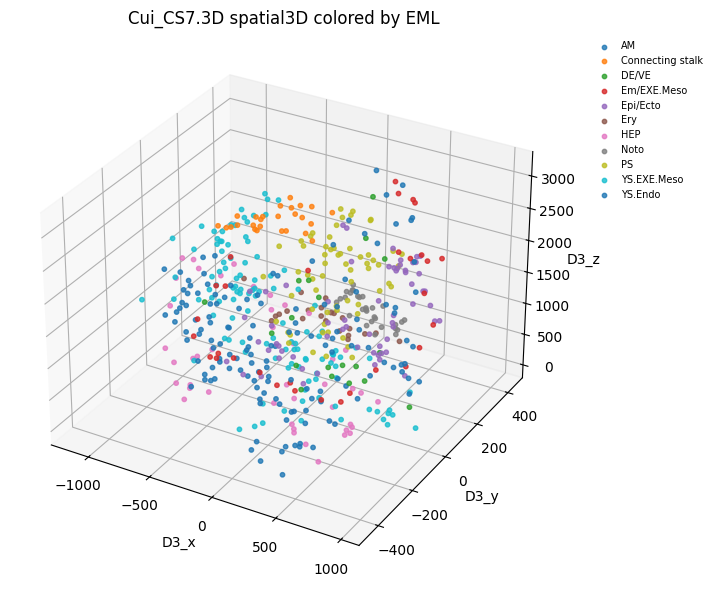

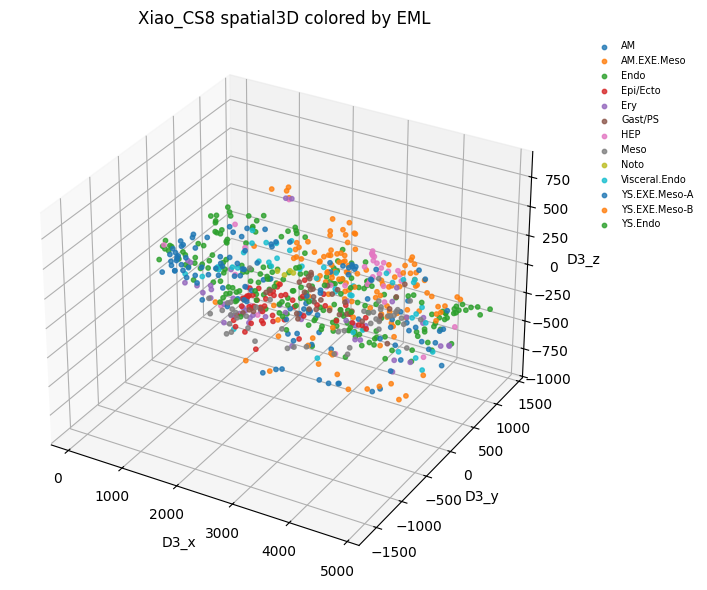

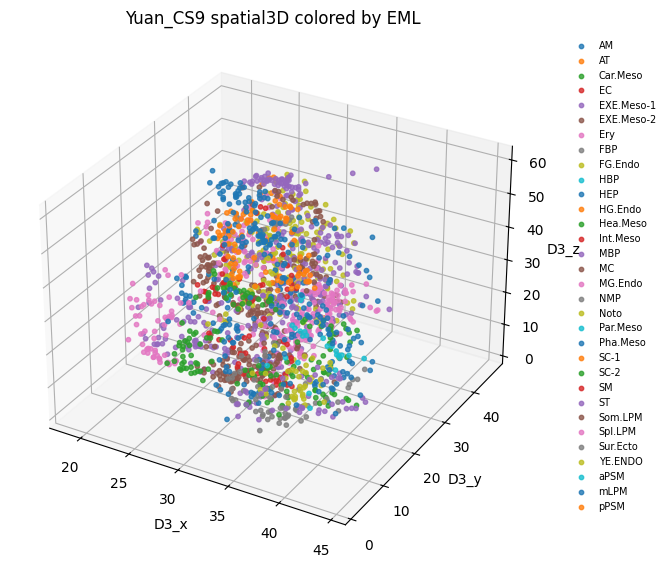

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

coords = pd.DataFrame(
    adata.obsm["spatial3D"],
    index=adata.obs_names,
    columns=["D3_x", "D3_y", "D3_z"]
)

color_key = "EML"

for sample in adata.obs["sample_key"].cat.categories:
    ad_idx = adata.obs["sample_key"] == sample
    c = coords.loc[ad_idx]
    labels = adata.obs.loc[ad_idx, color_key].astype(str)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    for lab in sorted(labels.unique()):
        idx = labels == lab
        ax.scatter(
            c.loc[idx, "D3_x"],
            c.loc[idx, "D3_y"],
            c.loc[idx, "D3_z"],
            s=10,
            alpha=0.8,
            label=lab
        )

    ax.set_title(f"{sample} spatial3D colored by {color_key}")
    ax.set_xlabel("D3_x")
    ax.set_ylabel("D3_y")
    ax.set_zlabel("D3_z")

    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=7,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key="sample_key"
)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


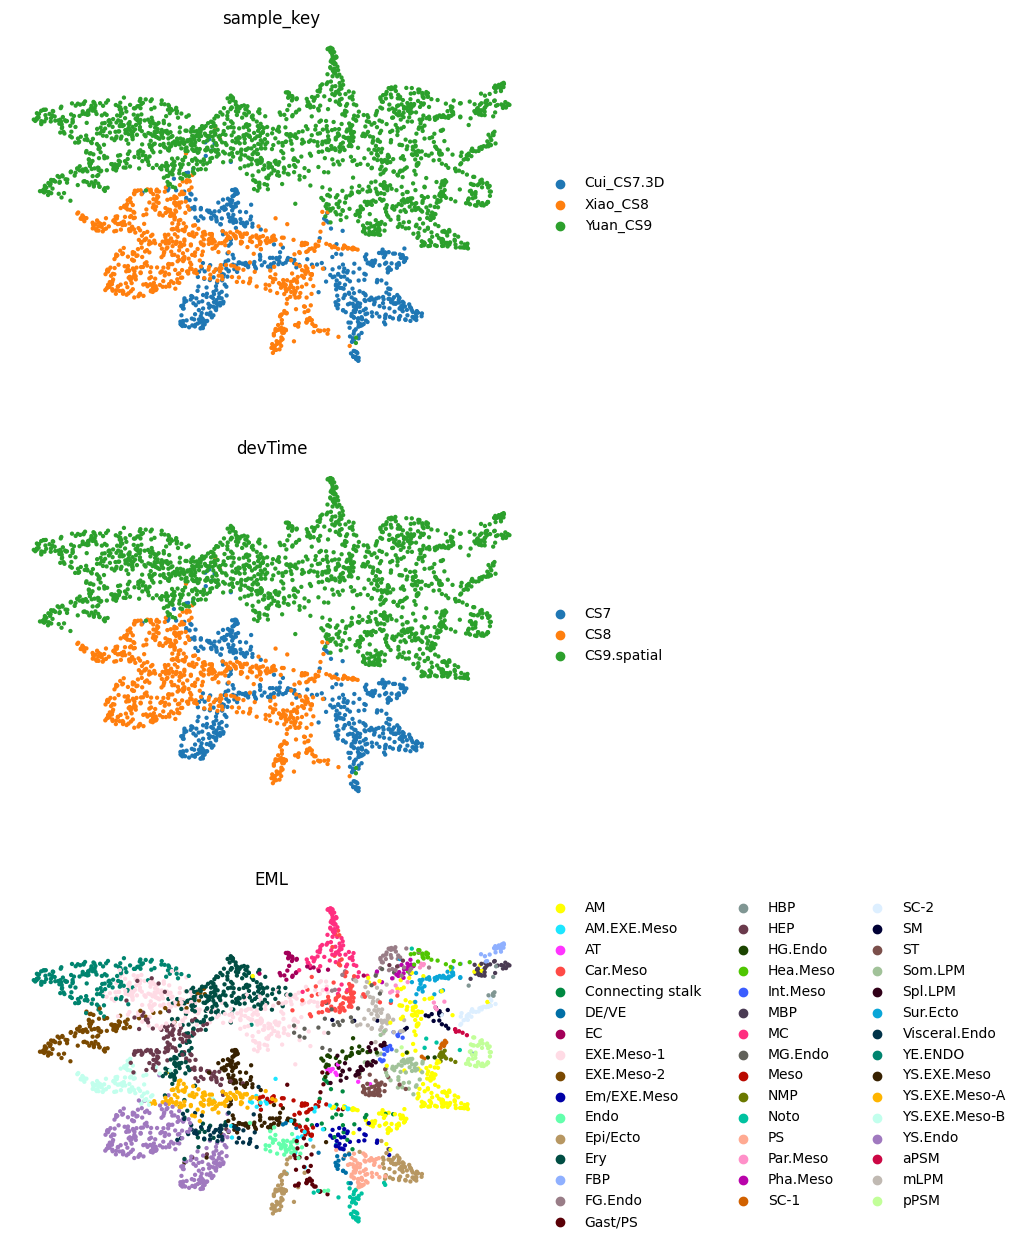

In [ ]:
sc.pl.umap(
    adata,
    color=["sample_key", "devTime", "EML"],
    frameon=False,
    ncols=1
)

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
os.chdir(project_dir)
sys.path.append(str(project_dir))

print(Path.cwd())

/mnt/yiming/nfs_share/projects/hypoblast


In [ ]:
fig_dir = Path("results/figures/401_lcxyw_merge")
fig_dir.mkdir(parents=True, exist_ok=True)

table_dir = Path("results/tables/401_lcxyw_merge")
table_dir.mkdir(parents=True, exist_ok=True)

processed_dir = Path("results/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [3]:
lanner_path = processed_dir / "lanner_psd_R3_6_raw_counts_log1p_prepared.h5ad"
wang_path = processed_dir / "wang_human_yolksac_cs10_11_processed_bbknn.h5ad"
spatial_path = Path('/mnt/yiming/nfs_share/projects/hypoblast/data/processed/temp.MC.raw_counts.h5ad')

In [4]:
lanner = sc.read_h5ad(lanner_path)
wang = sc.read_h5ad(wang_path)
spatial = sc.read_h5ad(spatial_path)

lanner, wang, spatial

(AnnData object with n_obs × n_vars = 3304 × 28866
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SID', 'batch', 'seqType', 'cellType', 'devTime', 'EML', 'subCT', 'libsize', 'nGene', 'pj', 'mt.perc', 'rename_EML', 'pup', 'SC', 'sub_rename_EML', 'publication'
     uns: 'log1p'
     obsm: 'X_UMAP', 'X_mnn'
     layers: 'counts', 'integration_input',
 AnnData object with n_obs × n_vars = 11021 × 20892
     obs: 'cell_id', 'age', 'stage', 'cluster', 'site', 'doublets', 'nCount_RNA', 'nFeature_RNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_r0.6', 'leiden_bbknn_r0.6'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'age_colors', 'cluster_colors', 'hvg', 'leiden_bbknn_r0.6', 'leiden_bbknn_r0.6_colors', 'leiden_r0.6', 'leiden_r0.6_colors', 'log1p', 'neighbors', 'pca', 'site_colors', 'stage_colors', 'umap'
     obsm: 'X_pca', 'X_umap

In [5]:
def ensure_counts_layer(adata, name):
    """
    Ensure adata.layers['counts'] contains raw counts.
    """
    if "counts" in adata.layers:
        adata.layers["counts"] = adata.layers["counts"].copy()
        print(f"{name}: using existing layers['counts']")
    else:
        adata.layers["counts"] = adata.X.copy()
        print(f"{name}: no counts layer; using X as counts")
    return adata


def clean_stage(x):
    """
    Standardize stage labels.
    Examples:
    CS9.spatial -> CS9
    CS7 -> CS7
    E6 -> E6
    """
    if pd.isna(x):
        return "Unknown"

    s = str(x)

    if s in ["nan", "None", "NaN", ""]:
        return "Unknown"

    if "CS7" in s:
        return "CS7"
    if "CS8" in s:
        return "CS8"
    if "CS9" in s:
        return "CS9"
    if "CS10" in s:
        return "CS10"
    if "CS11" in s:
        return "CS11"

    return s


def stage_to_development_day(stage):
    """
    Numeric stage/day used for sorting.
    For E stages, use E number directly.
    For CS stages, use approximate post-fertilization day.
    Adjust this mapping later if you want a different convention.
    """
    if pd.isna(stage):
        return np.nan

    s = str(stage)

    if s.startswith("E"):
        try:
            return float(s.replace("E", ""))
        except Exception:
            return np.nan

    cs_day_map = {
        "Zygote": 0.0,
        "CS7": 19.0,
        "CS8": 23.0,
        "CS9": 25.0,
        "CS10": 28.0,
        "CS11": 29.0,
    }

    return cs_day_map.get(s, np.nan)


def simplify_source_label(publication):
    if pd.isna(publication):
        return "Unknown"

    s = str(publication)

    fix_map = {
        "Yan et al": "Yan",
        "Yan et al.": "Yan",
        "Tyser et al": "Tyser",
        "Tyser et al.": "Tyser",
        "Meistermann et al": "Meistermann",
        "Meistermann et al.": "Meistermann",
        "Petropoulos et al": "Petropoulos",
        "Petropoulos et al.": "Petropoulos",
        "Xiang et al": "Xiang",
        "Xiang et al.": "Xiang",
        "Wang et al": "Wang",
        "Wang et al.": "Wang",
        "Cui et al": "Cui",
        "Cui et al.": "Cui",
        "Xiao et al": "Xiao",
        "Xiao et al.": "Xiao",
        "Yuan et al": "Yuan",
        "Yuan et al.": "Yuan",
    }

    if s in fix_map:
        return fix_map[s]

    s = (
        s.replace(" et al.", "")
         .replace(" et al", "")
         .strip()
    )

    if s in ["nan", "None", "NaN", ""]:
        return "Unknown"

    return s

In [6]:
lanner = ensure_counts_layer(lanner, "lanner")
wang = ensure_counts_layer(wang, "wang_ys")
spatial = ensure_counts_layer(spatial, "spatial_metacell")

lanner: using existing layers['counts']
wang_ys: using existing layers['counts']
spatial_metacell: using existing layers['counts']


In [7]:
lanner.obs["matrix_original"] = "lanner"
lanner.obs["modality"] = "sc"

# Keep original publication
if "publication" not in lanner.obs.columns:
    lanner.obs["publication"] = "Unknown"

lanner.obs["publication"] = lanner.obs["publication"].astype(str)

# Keep / assign reference group
if "reference_group" not in lanner.obs.columns:
    lanner.obs["reference_group"] = "early_embryo_atlas"

# Cell type and stage
lanner.obs["ref_celltype"] = lanner.obs["sub_rename_EML"].astype(str)
lanner.obs["ref_stage"] = lanner.obs["devTime"].map(clean_stage)

lanner.obs["development_day"] = lanner.obs["ref_stage"].map(stage_to_development_day)

lanner.obs["source_label"] = lanner.obs["publication"].map(simplify_source_label)

lanner.obs["source_stage"] = (
    lanner.obs["source_label"].astype(str)
    + "_"
    + lanner.obs["ref_stage"].astype(str)
)

In [8]:
wang.obs["matrix_original"] = "wang_ys"
wang.obs["modality"] = "sc"
wang.obs["reference_group"] = "wang_ys"

wang.obs["publication"] = "Wang et al"
wang.obs["source_label"] = "Wang"

wang.obs["ref_celltype"] = wang.obs["cluster"].astype(str)
wang.obs["ref_stage"] = wang.obs["stage"].map(clean_stage)

wang.obs["development_day"] = wang.obs["ref_stage"].map(stage_to_development_day)

wang.obs["source_stage"] = (
    wang.obs["source_label"].astype(str)
    + "_"
    + wang.obs["ref_stage"].astype(str)
)

In [9]:
spatial.obs["matrix_original"] = "spatial_metacell"
spatial.obs["modality"] = "spatial"
spatial.obs["reference_group"] = "spatial_metacell"

# ref_stage from devTime
spatial.obs["ref_stage"] = spatial.obs["devTime"].map(clean_stage)

# ref_celltype from EML
spatial.obs["ref_celltype"] = spatial.obs["EML"].astype(str)

# Publication/source_label by sample_key or stage
spatial.obs["publication"] = "Unknown"

spatial.obs.loc[
    spatial.obs["sample_key"].astype(str).eq("Cui_CS7.3D"),
    "publication"
] = "Cui et al"

spatial.obs.loc[
    spatial.obs["sample_key"].astype(str).eq("Xiao_CS8"),
    "publication"
] = "Xiao et al"

spatial.obs.loc[
    spatial.obs["sample_key"].astype(str).eq("Yuan_CS9"),
    "publication"
] = "Yuan et al"

# Fallback by ref_stage
spatial.obs.loc[
    spatial.obs["ref_stage"].astype(str).eq("CS7") & spatial.obs["publication"].eq("Unknown"),
    "publication"
] = "Cui et al"

spatial.obs.loc[
    spatial.obs["ref_stage"].astype(str).eq("CS8") & spatial.obs["publication"].eq("Unknown"),
    "publication"
] = "Xiao et al"

spatial.obs.loc[
    spatial.obs["ref_stage"].astype(str).eq("CS9") & spatial.obs["publication"].eq("Unknown"),
    "publication"
] = "Yuan et al"

spatial.obs["source_label"] = spatial.obs["publication"].map(simplify_source_label)

spatial.obs["development_day"] = spatial.obs["ref_stage"].map(stage_to_development_day)

spatial.obs["source_stage"] = (
    spatial.obs["source_label"].astype(str)
    + "_"
    + spatial.obs["ref_stage"].astype(str)
)

In [10]:
for ad in [lanner, wang, spatial]:
    ad.obs["dataset"] = ad.obs["source_label"].astype(str)
    ad.obs["dataset_stage"] = ad.obs["source_stage"].astype(str)

    ad.obs["display_label"] = (
        ad.obs["source_stage"].astype(str)
        + " | "
        + ad.obs["ref_celltype"].astype(str)
    )

    ad.obs["publication_stage_celltype"] = (
        ad.obs["publication"].astype(str)
        + " | "
        + ad.obs["ref_stage"].astype(str)
        + " | "
        + ad.obs["ref_celltype"].astype(str)
    )

In [11]:
required_meta_cols = [
    "matrix_original",
    "modality",
    "reference_group",
    "publication",
    "source_label",
    "ref_stage",
    "development_day",
    "source_stage",
    "ref_celltype",
]

for name, ad in {
    "lanner": lanner,
    "spatial": spatial,
    "wang": wang,
}.items():
    print("\n" + "=" * 80)
    print(name)
    print(ad.shape)

    missing = [c for c in required_meta_cols if c not in ad.obs.columns]
    print("missing required columns:", missing)

    display(
        ad.obs[
            required_meta_cols
        ]
        .drop_duplicates()
        .sort_values(["development_day", "source_label", "ref_stage"])
        .head(30)
    )


lanner
(3304, 28866)
missing required columns: []


,matrix_original,modality,reference_group,publication,source_label,ref_stage,development_day,source_stage,ref_celltype
barcode,,,,,,,,,
sc7785290,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,Blood_Progenitors
sc7786612,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,DE
sc7786605,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,AdvMes
sc7785737,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,PriS
sc7785398,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,ExE_Mes
sc7788091,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,Axial Mes
sc7785785,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,Erythroblasts
sc7785611,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,YSE
sc7786585,lanner,sc,early_embryo_atlas,Tyser et al,Tyser,CS7,19.0,Tyser_CS7,Mesoderm



spatial
(3106, 30212)
missing required columns: []


,matrix_original,modality,reference_group,publication,source_label,ref_stage,development_day,source_stage,ref_celltype
CS7.3D.SEACell.0__MSsub_1,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,YS.Endo
CS7.3D.SEACell.100__MSsub_2,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,Epi/Ecto
CS7.3D.SEACell.101__MSsub_1,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,Ery
CS7.3D.SEACell.103__MSsub_3,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,Connecting stalk
CS7.3D.SEACell.104__MSsub_3,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,HEP
CS7.3D.SEACell.105__MSsub_1,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,YS.EXE.Meso
CS7.3D.SEACell.112__MSsub_1,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,PS
CS7.3D.SEACell.113__MSsub_2,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,AM
CS7.3D.SEACell.118__MSsub_1,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,DE/VE
CS7.3D.SEACell.119__MSsub_2,spatial_metacell,spatial,spatial_metacell,Cui et al,Cui,CS7,19.0,Cui_CS7,Noto



wang
(11021, 20892)
missing required columns: []


,matrix_original,modality,reference_group,publication,source_label,ref_stage,development_day,source_stage,ref_celltype
AAACCTGAGACCTTTG_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,EC
AAACCTGCACCTATCC_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,Ery
AAACCTGCACTTAAGC_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,YSMP2
AAACCTGGTGTGAATA_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,Epi
AAACGGGCAAACAACA_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,MK
AAACGGGGTCCTCCAT_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,Mac
AAACGGGTCTCGAGTA_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,MEP
AACACGTAGTACCGGA_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,Mes
AACACGTCATCTATGG_1,wang_ys,sc,wang_ys,Wang et al,Wang,CS10,28.0,Wang_CS10,YSMP1
AAACCTGAGACTGGGT_2,wang_ys,sc,wang_ys,Wang et al,Wang,CS11,29.0,Wang_CS11,MK


In [12]:
def prepare_from_counts_for_integration(adata, name):
    """
    Keep raw counts in layers['counts'].
    Set X and layers['integration_input'] to log1p-normalized expression.
    """
    print(f"{name}: prepare integration input from raw counts")

    adata.X = adata.layers["counts"].copy()

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata.layers["integration_input"] = adata.X.copy()
    return adata


lanner = prepare_from_counts_for_integration(lanner, "lanner")
wang = prepare_from_counts_for_integration(wang, "wang_ys")
spatial = prepare_from_counts_for_integration(spatial, "spatial_metacell")

lanner: prepare integration input from raw counts


wang_ys: prepare integration input from raw counts
spatial_metacell: prepare integration input from raw counts


In [13]:
common_genes = set(lanner.var_names)
common_genes &= set(wang.var_names)
common_genes &= set(spatial.var_names)
common_genes = sorted(common_genes)

print("Common genes:", len(common_genes))

Common genes: 17024


In [20]:
lanner_sub = lanner[:, common_genes].copy()
spatial_sub = spatial[:, common_genes].copy()
wang_sub = wang[:, common_genes].copy()

adata_ref = sc.concat(
    {
        "lanner": lanner_sub,
        "spatial_metacell": spatial_sub,
        "wang_ys": wang_sub,
    },
    label="matrix_original",
    join="inner",
    merge="same",
    index_unique="-",
)

adata_ref.var_names_make_unique()

# Keep log-normalized input
adata_ref.layers["log1p_norm"] = adata_ref.X.copy()

# Make sure matrix_original uses requested labels, not concat labels if already present
adata_ref.obs["matrix_original"] = adata_ref.obs["matrix_original"].astype(str)

adata_ref

/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


AnnData object with n_obs × n_vars = 17431 × 17024
    obs: 'publication', 'matrix_original', 'modality', 'reference_group', 'ref_celltype', 'ref_stage', 'development_day', 'source_label', 'source_stage', 'dataset', 'dataset_stage', 'display_label', 'publication_stage_celltype'
    layers: 'counts', 'integration_input', 'log1p_norm'

In [21]:
required_meta_cols = [
    "matrix_original",
    "modality",
    "reference_group",
    "publication",
    "source_label",
    "ref_stage",
    "development_day",
    "source_stage",
    "ref_celltype",
]

for c in required_meta_cols:
    if c not in adata_ref.obs.columns:
        raise ValueError(f"Missing required metadata column: {c}")

summary_cols = [
    "matrix_original",
    "modality",
    "reference_group",
    "publication",
    "source_label",
    "ref_stage",
    "development_day",
    "source_stage",
]

source_summary = (
    adata_ref.obs[summary_cols]
    .drop_duplicates()
    .sort_values(["development_day", "matrix_original", "source_label", "ref_stage"])
)

source_summary

,matrix_original,modality,reference_group,publication,source_label,ref_stage,development_day,source_stage
Yan_SRR445722-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,Zygote,0.0,Yan_Zygote
Yan_SRR445724-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E1,1.0,Yan_E1
Yan_SRR490961-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E2,2.0,Yan_E2
E3.1.443-lanner,lanner,sc,early_embryo_atlas,Petropoulos et al,Petropoulos,E3,3.0,Petropoulos_E3
Yan_SRR490973-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E3,3.0,Yan_E3
Meis_M30C10-lanner,lanner,sc,early_embryo_atlas,Meistermann et al,Meistermann,E4,4.0,Meistermann_E4
E4.10.1219-lanner,lanner,sc,early_embryo_atlas,Petropoulos et al,Petropoulos,E4,4.0,Petropoulos_E4
Yan_SRR490994-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E4,4.0,Yan_E4
Meis_B11C3-lanner,lanner,sc,early_embryo_atlas,Meistermann et al,Meistermann,E5,5.0,Meistermann_E5
E5.15.1820-lanner,lanner,sc,early_embryo_atlas,Petropoulos et al,Petropoulos,E5,5.0,Petropoulos_E5


In [22]:
celltype_summary = (
    adata_ref.obs[
        summary_cols + ["ref_celltype", "display_label", "publication_stage_celltype"]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "development_day",
            "matrix_original",
            "source_label",
            "ref_stage",
            "ref_celltype",
        ]
    )
)

celltype_summary

,matrix_original,modality,reference_group,publication,source_label,ref_stage,development_day,source_stage,ref_celltype,display_label,publication_stage_celltype
Yan_SRR445722-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,Zygote,0.0,Yan_Zygote,Zygote,Yan_Zygote | Zygote,Yan et al | Zygote | Zygote
Yan_SRR445724-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E1,1.0,Yan_E1,2-4 cell,Yan_E1 | 2-4 cell,Yan et al | E1 | 2-4 cell
Yan_SRR490961-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E2,2.0,Yan_E2,2-4 cell,Yan_E2 | 2-4 cell,Yan et al | E2 | 2-4 cell
E3.1.443-lanner,lanner,sc,early_embryo_atlas,Petropoulos et al,Petropoulos,E3,3.0,Petropoulos_E3,8 cell,Petropoulos_E3 | 8 cell,Petropoulos et al | E3 | 8 cell
Yan_SRR490973-lanner,lanner,sc,early_embryo_atlas,Yan et al,Yan,E3,3.0,Yan_E3,8 cell,Yan_E3 | 8 cell,Yan et al | E3 | 8 cell
...,...,...,...,...,...,...,...,...,...,...,...
AAACCTGAGACTGGGT_2-wang_ys,wang_ys,sc,wang_ys,Wang et al,Wang,CS11,29.0,Wang_CS11,MK,Wang_CS11 | MK,Wang et al | CS11 | MK
AAACCTGCATCCAACA_2-wang_ys,wang_ys,sc,wang_ys,Wang et al,Wang,CS11,29.0,Wang_CS11,Mac,Wang_CS11 | Mac,Wang et al | CS11 | Mac
AAACCTGGTCCAACTA_2-wang_ys,wang_ys,sc,wang_ys,Wang et al,Wang,CS11,29.0,Wang_CS11,Mes,Wang_CS11 | Mes,Wang et al | CS11 | Mes
AAACCTGAGGCTAGAC_2-wang_ys,wang_ys,sc,wang_ys,Wang et al,Wang,CS11,29.0,Wang_CS11,YSMP1,Wang_CS11 | YSMP1,Wang et al | CS11 | YSMP1


In [23]:
adata_ref.obs

,publication,matrix_original,modality,reference_group,ref_celltype,ref_stage,development_day,source_label,source_stage,dataset,dataset_stage,display_label,publication_stage_celltype
Yan_SRR491011-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,Yan_E6,Yan_E6 | TE,Yan et al | E6 | TE
Yan_SRR491012-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,Yan_E6,Yan_E6 | TE,Yan et al | E6 | TE
Yan_SRR491013-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,Yan_E6,Yan_E6 | TE,Yan et al | E6 | TE
Yan_SRR491014-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,Yan_E6,Yan_E6 | TE,Yan et al | E6 | TE
Yan_SRR491015-lanner,Yan et al,lanner,sc,early_embryo_atlas,TE,E6,6.0,Yan,Yan_E6,Yan,Yan_E6,Yan_E6 | TE,Yan et al | E6 | TE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGTGTGAAT_2-wang_ys,Wang et al,wang_ys,sc,wang_ys,Ery,CS11,29.0,Wang,Wang_CS11,Wang,Wang_CS11,Wang_CS11 | Ery,Wang et al | CS11 | Ery
TTTGTCACAGACAAAT_2-wang_ys,Wang et al,wang_ys,sc,wang_ys,EC,CS11,29.0,Wang,Wang_CS11,Wang,Wang_CS11,Wang_CS11 | EC,Wang et al | CS11 | EC
TTTGTCACATCGGGTC_2-wang_ys,Wang et al,wang_ys,sc,wang_ys,MK,CS11,29.0,Wang,Wang_CS11,Wang,Wang_CS11,Wang_CS11 | MK,Wang et al | CS11 | MK
TTTGTCACATCGTCGG_2-wang_ys,Wang et al,wang_ys,sc,wang_ys,MK,CS11,29.0,Wang,Wang_CS11,Wang,Wang_CS11,Wang_CS11 | MK,Wang et al | CS11 | MK


In [24]:
adata_ref.obs.columns

Index(['publication', 'matrix_original', 'modality', 'reference_group',
       'ref_celltype', 'ref_stage', 'development_day', 'source_label',
       'source_stage', 'dataset', 'dataset_stage', 'display_label',
       'publication_stage_celltype'],
      dtype='object')

In [25]:
adata_ref.write_h5ad('/mnt/yiming/nfs_share/projects/hypoblast/results/processed/lcxyw_merged.h5ad')

In [2]:
import scanpy as sc
adata = sc.read_h5ad('/mnt/yiming/nfs_share/projects/hypoblast/results/processed/lcxyw_merged.h5ad')

In [3]:
adata.obs['development_day'].value_counts()

development_day
29.0    7309
28.0    3712
25.0    1814
19.0    1726
23.0     736
6.0      548
7.0      543
5.0      335
4.0      190
14.0     128
12.0      85
3.0       84
10.0      75
9.0       68
8.0       58
2.0       12
1.0        6
0.0        2
Name: count, dtype: int64

In [ ]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
os.chdir(project_dir)
sys.path.append(str(project_dir))

processed_dir = Path("results/processed")
fig_dir = Path("results/figures/fastmnn_lcxyw_v3")
table_dir = Path("results/tables/fastmnn_lcxyw_v3")

fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

adata_path = Path('/mnt/yiming/nfs_share/projects/hypoblast/results/processed/lcxyw_merged.h5ad')
fastmnn_dir = processed_dir / "fastmnn_lcxyw_v3"

pcs_path = fastmnn_dir / "fastmnn_corrected_pcs.tsv"
meta_path = fastmnn_dir / "fastmnn_cell_metadata.tsv"

adata_ref = sc.read_h5ad(adata_path)

fastmnn_pcs = pd.read_csv(
    pcs_path,
    sep="\t",
    index_col=0,
)

fastmnn_meta = pd.read_csv(
    meta_path,
    sep="\t",
)

adata_ref, fastmnn_pcs.shape, fastmnn_meta.shape

(AnnData object with n_obs × n_vars = 17431 × 17024
     obs: 'publication', 'matrix_original', 'modality', 'reference_group', 'ref_celltype', 'ref_stage', 'development_day', 'source_label', 'source_stage', 'dataset', 'dataset_stage', 'display_label', 'publication_stage_celltype'
     layers: 'counts', 'integration_input', 'log1p_norm',
 (17431, 50),
 (17431, 2))

In [ ]:
adata_ref.obs["development_day"] = pd.to_numeric(
    adata_ref.obs["development_day"].astype(str),
    errors="coerce"
).astype(float)

adata_ref.obs["development_day"].dtype

dtype('float64')

In [ ]:
ref_stage_order = [
    "Zygote",
    "E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10", "E12", "E14",
    "CS7", "CS8", "CS9", "CS10", "CS11",
]

adata_ref.obs["ref_stage"] = pd.Categorical(
    adata_ref.obs["ref_stage"].astype(str),
    categories=ref_stage_order,
    ordered=True,
)

In [ ]:
# compute new neighbors and UMAP using R fastMNN PCs
sc.pp.neighbors(
    adata_ref,
    use_rep="X_fastmnn_R",
    n_neighbors=20,
    random_state=0,
)

sc.tl.umap(
    adata_ref,
    random_state=0,
)

adata_ref.obsm["X_umap_fastmnn_R"] = adata_ref.obsm["X_umap"].copy()

In [ ]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)

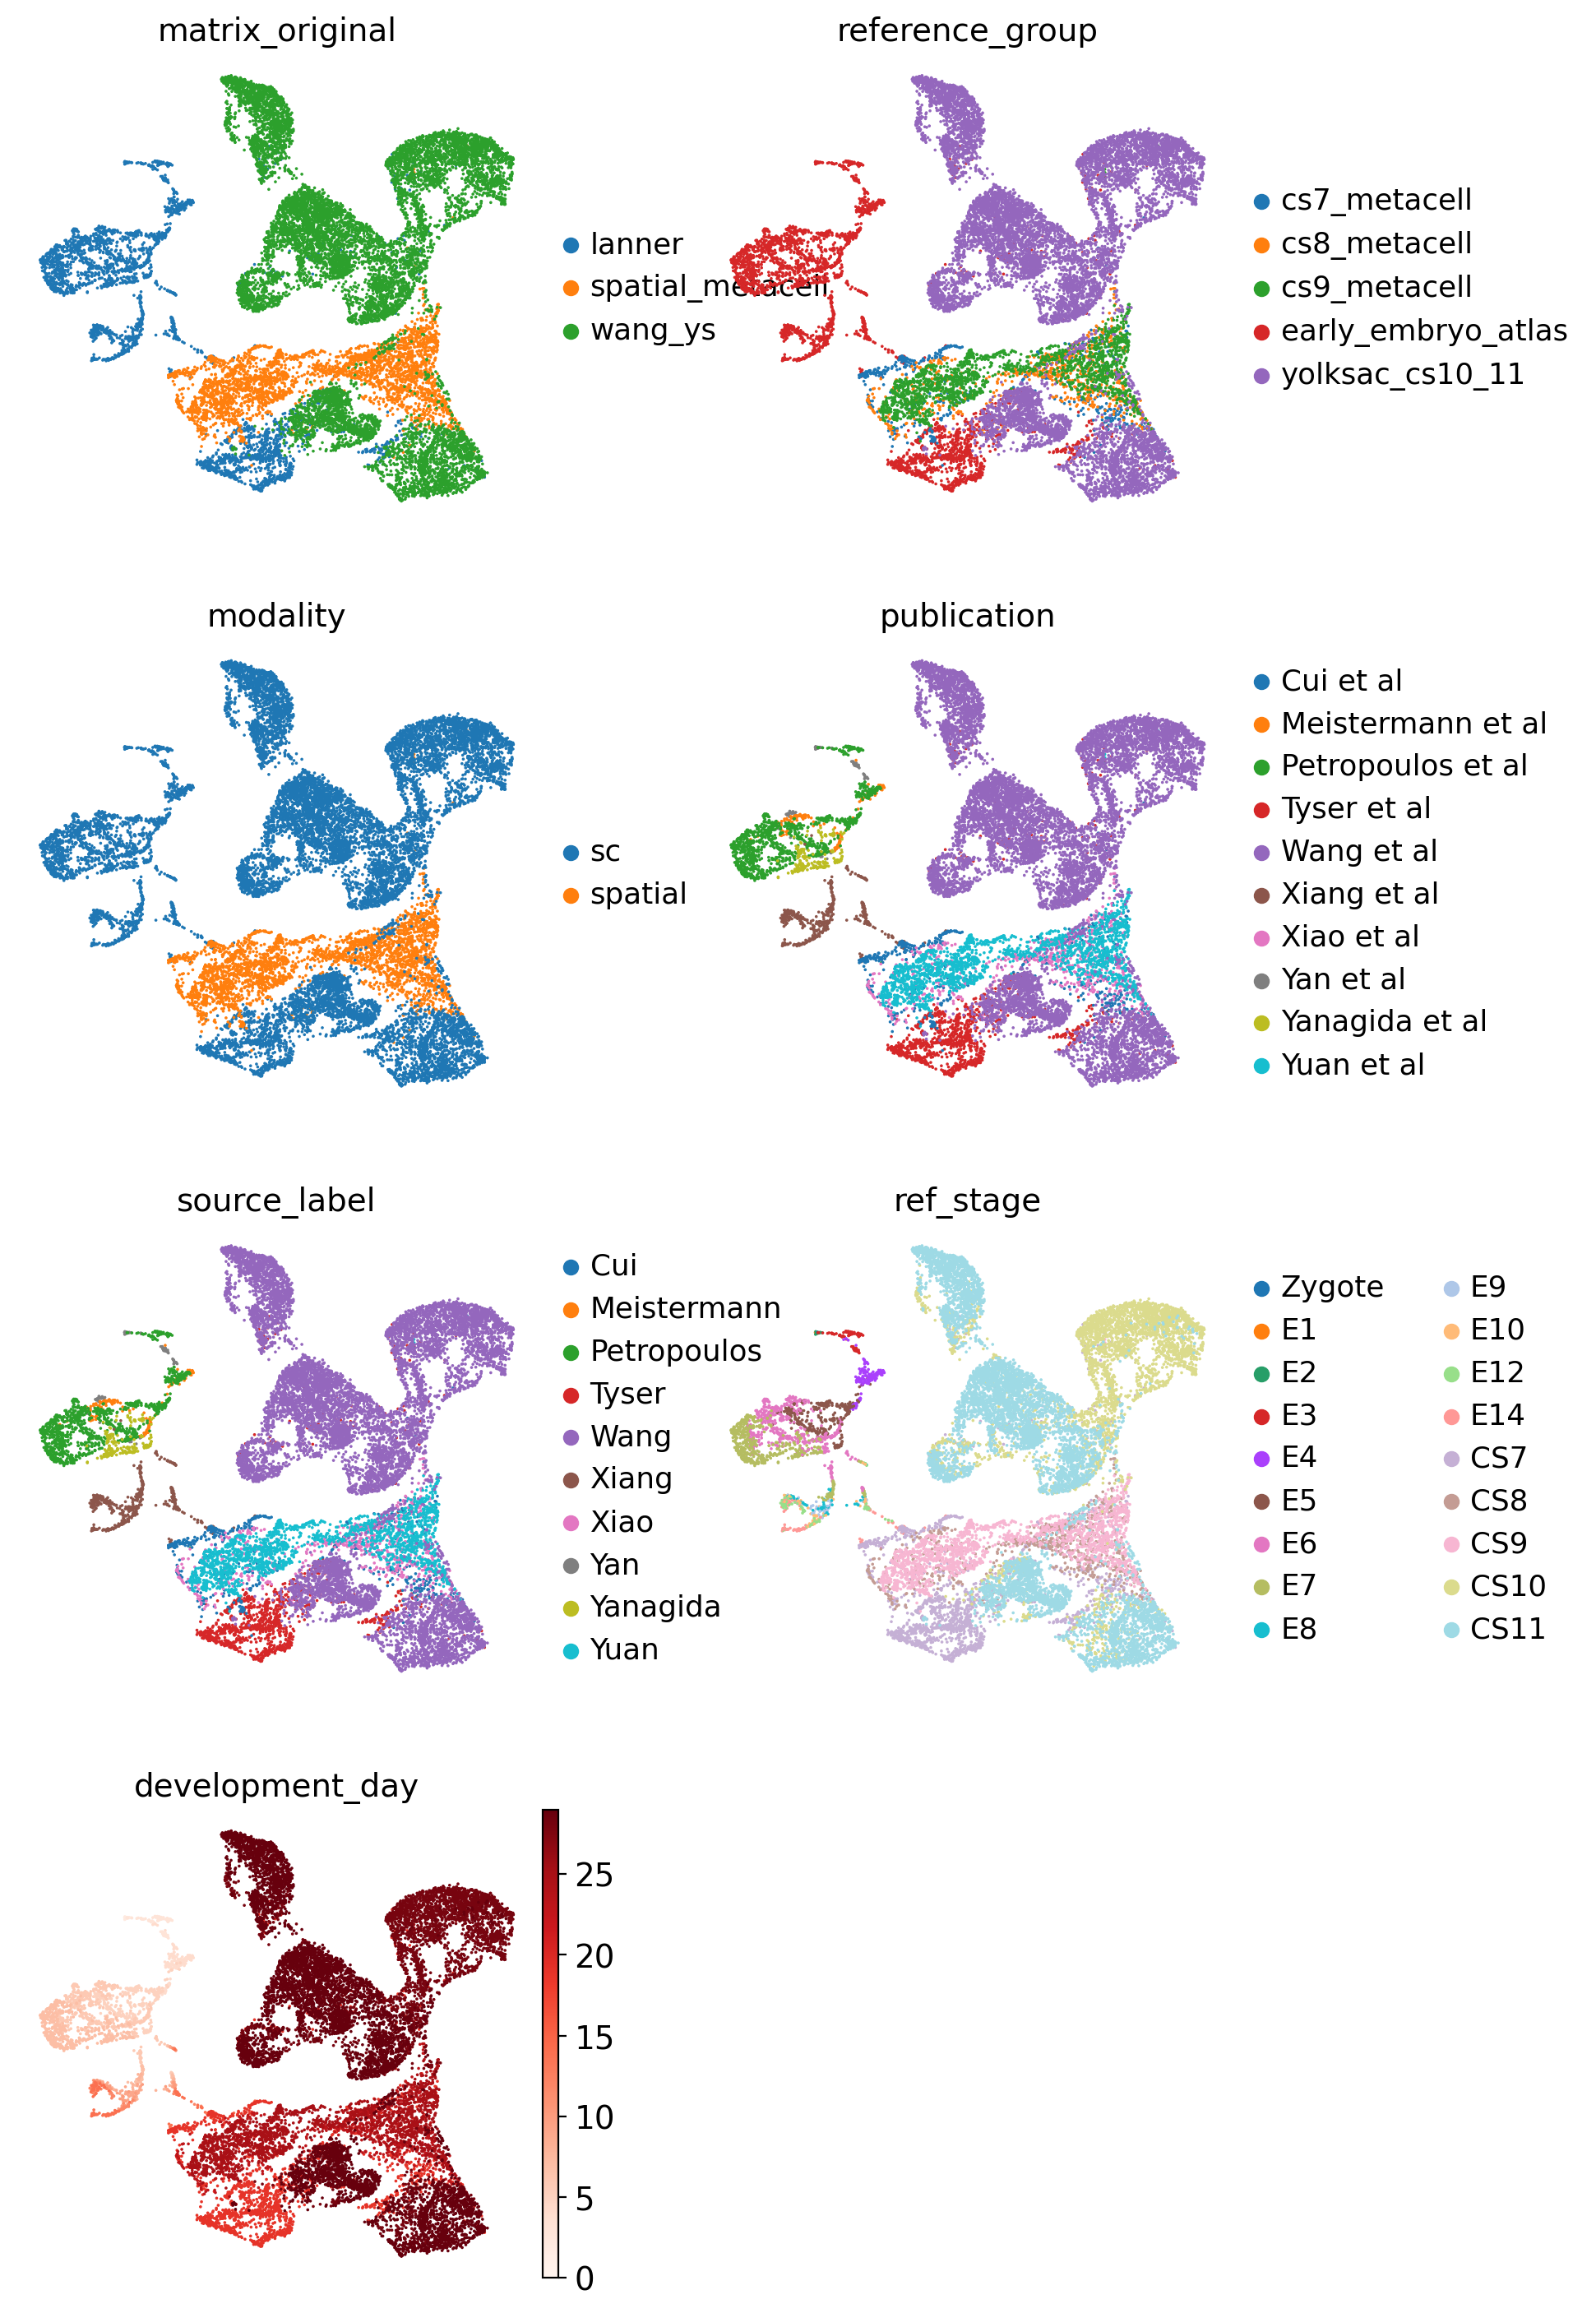

In [ ]:
# plot metadata overview
sc.pl.umap(
    adata_ref,
    color=[
        "matrix_original",
        "reference_group",
        "modality",
        "publication",
        "source_label",
        "ref_stage",
        "development_day",
    ],
    frameon=False,
    ncols=2,
    cmap="Reds",
    show=False,
)

plt.savefig(
    fig_dir / "fastmnn_R_umap_metadata_overview.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    fig_dir / "fastmnn_R_umap_metadata_overview.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [ ]:
# adata_ref.write_h5ad('/mnt/yiming/nfs_share/projects/hypoblast/results/processed/lcxyw_fastmnn_v3.h5ad')

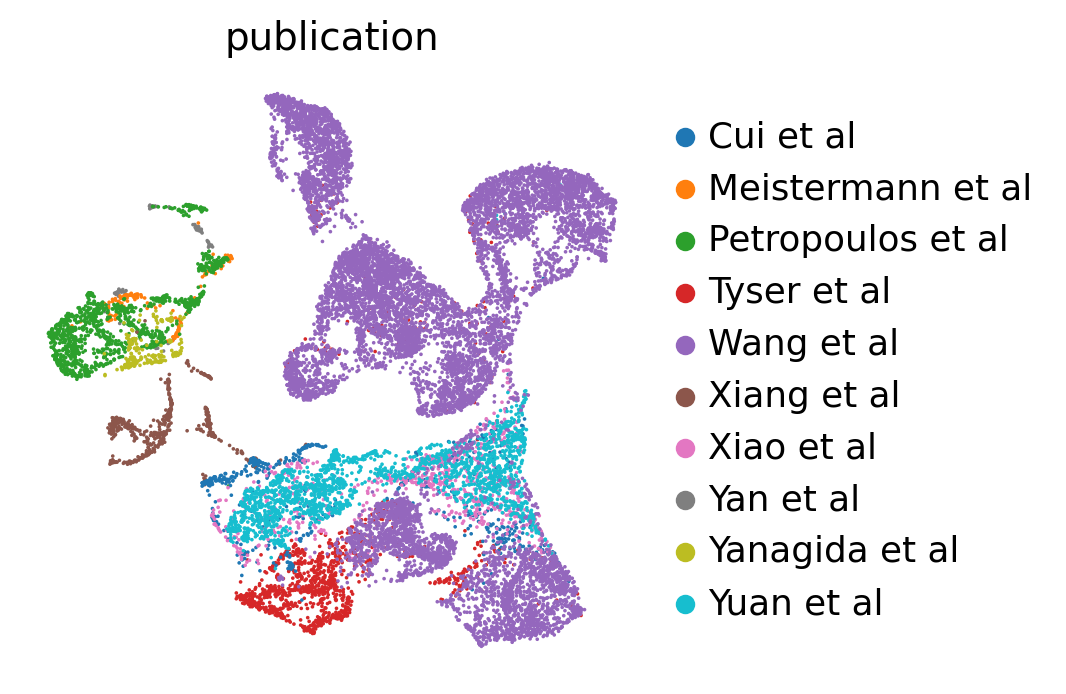

In [ ]:
sc.pl.umap(adata_ref, color='publication', 
           frameon=False, 
           save='_publication.pdf')

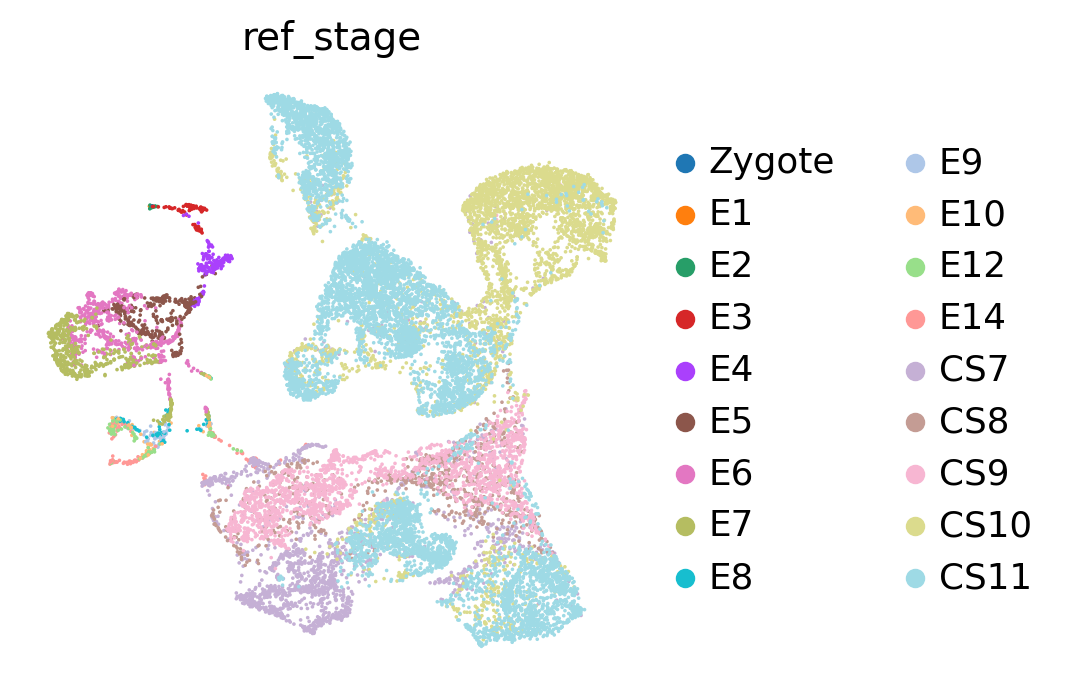

In [ ]:
sc.pl.umap(adata_ref, color='ref_stage', 
           frameon=False, 
           save='_ref_stage.pdf')

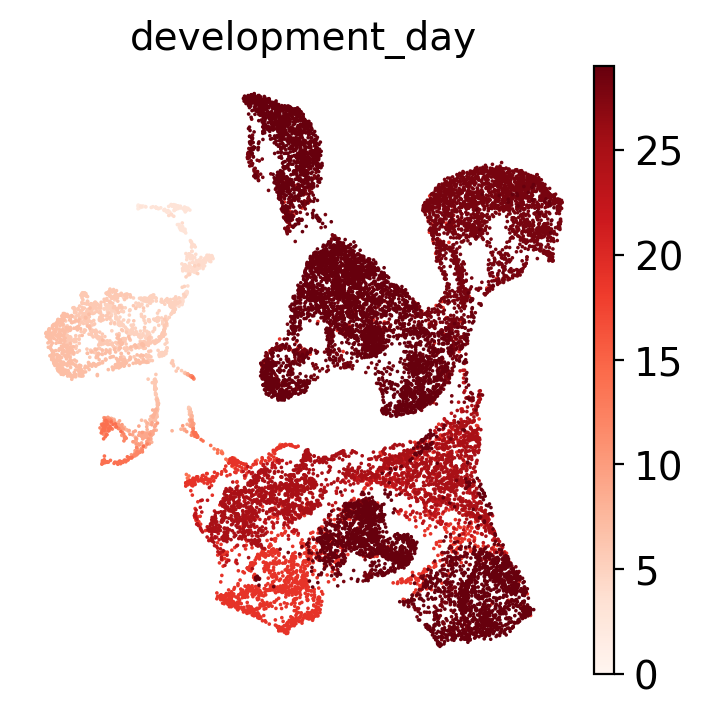

In [ ]:
sc.pl.umap(adata_ref, color='development_day', 
           frameon=False, cmap='Reds',
           save='_development_day.pdf')

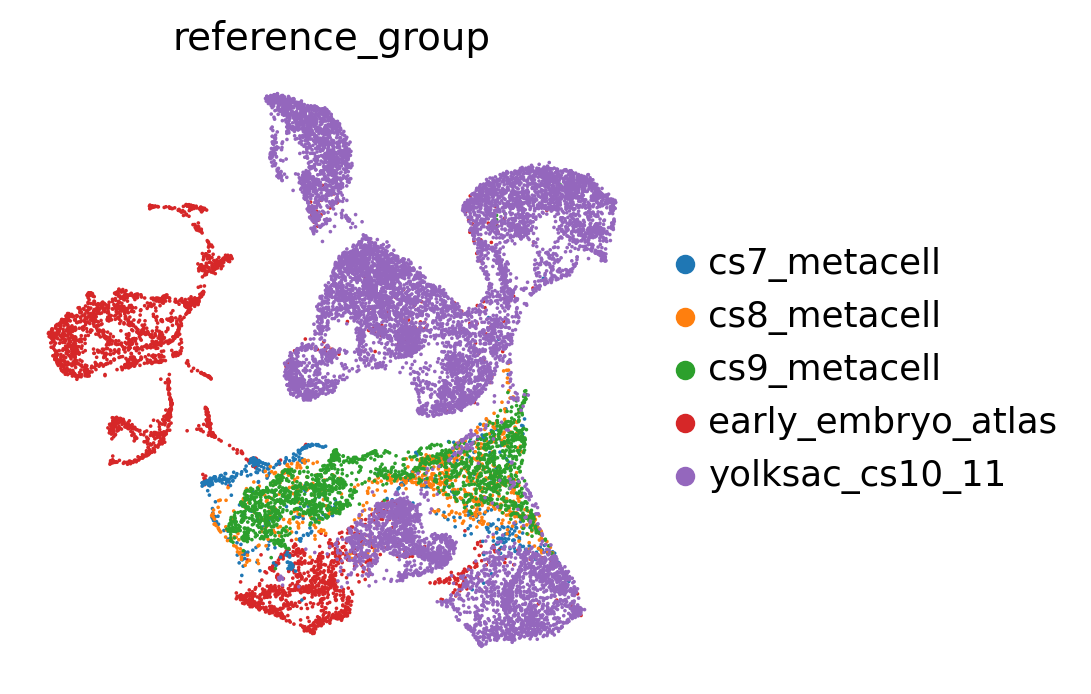

In [ ]:
sc.pl.umap(adata_ref, color='reference_group', 
           frameon=False, 
           save='_reference_group.pdf')